**Word Bank Indicators PANDAS project**

#Analysis of World Bank WDI Data for India, China, and the USA

In this notebook we analyze key development indicators – GDP growth (annual %), Total population, Life expectancy at birth, and CO₂ emissions (metric tons per capita) – for India, China, and the United States using the provided World Bank WDI dataset (wide format). We perform data cleaning and filtering without reshaping to long form, then apply grouping, aggregation, ranking, and percentage-change operations. Finally, we visualize trends using line, bar, and scatter plots. Each section includes Python code and a clear explanation of the Pandas operations, with relevant references.

# 1. Data Loading and Cleaning (Wide Format)

In the WDI wide-format CSV, each row corresponds to a country-indicator pair, and columns include metadata plus one column per year (e.g. 1960, 1961, ..., 2020). The snippet above reads the file into a DataFrame and prints its shape and first few columns. We ensure column names are clean (no leading/trailing spaces) and confirm the year columns are present. For example, the first few columns might be ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '1960', ...].

Explanation: We use pd.read_csv to load the data. In a wide-format dataset like this, the year columns are currently strings. We may keep them as strings or convert to integers for convenience. Data cleaning here might include trimming whitespace from column names (e.g. df.columns = df.columns.str.strip()) and handling any missing values (df.dropna() or df.fillna()) if necessary. Wide format means we do not melt or pivot unless explicitly needed.

In [ ]:


import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/WB_WDI_WIDEF.csv")
df.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MDA,WB_WDI_AG_LND_FRST_ZS,_T,_T,_T,PT_LAR,...,1.175182e+01,1.175487e+01,1.175129e+01,1.175297e+01,1.175276e+01,1.175322e+01,1.175129e+01,1.175487e+01,1.173702e+01,NaN
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,PSE,WB_WDI_NY_GDP_FCST_KD,_T,_T,_T,USD_K_2015,...,1.194880e+10,1.304710e+10,1.307280e+10,1.331750e+10,1.349400e+10,1.187960e+10,1.261870e+10,1.279850e+10,1.187650e+10,8.720200e+09
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ECU,WB_WDI_AG_LND_PRCP_MM,_T,_T,_T,MM_Y,...,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,NaN,NaN
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SMR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,2.291506e+00,2.344406e+00,2.582655e-01,1.493905e+00,2.065685e+00,-6.647911e+00,1.389779e+01,7.898441e+00,4.019349e-01,NaN
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,NZL,WB_WDI_NY_TAX_NIND_KN,_T,_T,_T,XDC_K,...,2.341540e+10,2.453566e+10,2.549904e+10,2.645277e+10,2.701978e+10,2.642800e+10,2.788406e+10,2.952042e+10,2.952592e+10,NaN


In [ ]:
#the code df.shape returns a tuple representing the dimensions of the DataFrame df.
#The output (294796, 106) means that the DataFrame df has 294,796 rows and 106 columns.


print(f"Dataset shape: {df.shape}")
print("Sample columns:", df.columns[:6].tolist())
print(df.columns)

Dataset shape: (294796, 106)
Sample columns: ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR']
Index(['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR',
       'SEX', 'AGE', 'URBANISATION', 'UNIT_MEASURE',
       ...
       '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023',
       '2024'],
      dtype='object', length=106)


# consise summary of the dataframe

The df.info() method in pandas is used to print a concise summary of a DataFrame. This summary includes important information like the index dtype, column dtypes, non-null values, and memory usage. It's a very useful function for a quick overview of your data's structure and completeness.

The df.describe() method generates descriptive statistics of the DataFrame columns. For numerical columns, it provides statistics like count, mean, standard deviation, min, max, and quartile values. This gives you a quick statistical summary and helps you understand the distribution and central tendency of your data.

The code df.isnull().sum() is a very useful command in Pandas for understanding the completeness of your dataset. It works by first creating a boolean DataFrame where True indicates a missing (NaN) value and False indicates a non-missing value. Then, .sum() counts the True values for each column, effectively showing you the total number of missing values in each column of your df DataFrame.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 294796 entries, 0 to 294795
Columns: 106 entries, STRUCTURE to 2024
dtypes: float64(65), int64(2), object(39)
memory usage: 238.4+ MB


In [ ]:
df.describe()

,DECIMALS,UNIT_MULT,1960,1961,1962,1963,1964,1965,1966,1967,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
count,294796.0,294796.000000,3.736300e+04,4.269800e+04,4.398300e+04,4.491700e+04,4.541900e+04,4.725100e+04,4.751800e+04,4.816600e+04,...,2.323600e+05,2.302510e+05,2.292290e+05,2.285080e+05,2.237710e+05,2.197880e+05,2.150960e+05,2.006860e+05,1.780600e+05,1.173550e+05
mean,2.0,0.036493,1.859632e+12,1.732413e+12,1.777017e+12,1.845434e+12,1.998414e+12,2.229339e+12,2.427028e+12,2.691688e+12,...,5.122781e+12,5.721701e+12,6.074613e+12,6.326645e+12,3.073197e+13,3.781215e+14,2.014598e+15,1.537940e+16,6.146628e+16,2.075905e+17
std,0.0,0.509485,9.542519e+13,9.631023e+13,1.012284e+14,1.070760e+14,1.159539e+14,1.326156e+14,1.458979e+14,1.626646e+14,...,3.577798e+14,3.961560e+14,4.166271e+14,4.036979e+14,1.140412e+16,1.737342e+17,9.299193e+17,6.883885e+18,2.592953e+19,7.110348e+19
min,2.0,0.000000,-6.983892e+14,-1.048260e+15,-1.190074e+15,-1.321699e+15,-1.403476e+15,-1.815444e+15,-2.305316e+15,-2.572435e+15,...,-4.574721e+14,-3.970130e+14,-4.306058e+14,-4.421837e+14,-3.551874e+15,-6.131892e+15,-4.608969e+14,-5.290986e+14,-3.846495e+15,-1.067341e+16
25%,2.0,0.000000,4.455914e+00,4.512997e+00,4.573635e+00,4.647541e+00,4.734225e+00,4.499788e+00,4.761900e+00,4.738790e+00,...,5.109969e+00,5.000000e+00,5.191000e+00,4.761905e+00,5.157763e+00,4.710969e+00,5.604799e+00,5.570151e+00,5.588314e+00,5.771942e+00
50%,2.0,0.000000,3.636700e+01,3.747798e+01,3.650336e+01,3.600000e+01,3.699882e+01,3.710000e+01,3.969153e+01,4.044547e+01,...,3.730896e+01,3.691380e+01,3.878000e+01,3.598114e+01,3.809524e+01,3.719235e+01,3.949433e+01,4.106110e+01,4.385725e+01,4.737883e+01
75%,2.0,0.000000,9.133300e+04,8.000000e+04,7.080000e+04,7.095900e+04,8.276800e+04,1.167215e+05,1.532004e+05,1.967100e+05,...,4.502115e+03,3.823806e+03,4.642000e+03,4.443951e+03,6.537500e+03,7.592750e+03,7.880000e+03,9.695390e+03,3.113425e+04,5.243020e+05
max,2.0,9.000000,7.617957e+15,8.409533e+15,9.074665e+15,9.713710e+15,1.053697e+16,1.233202e+16,1.375050e+16,1.529781e+16,...,6.671853e+16,7.248544e+16,7.646208e+16,7.002421e+16,5.391345e+18,8.144900e+19,4.312820e+20,3.083842e+21,1.094152e+22,2.435800e+22


In [ ]:
df.isnull().sum()


,0
STRUCTURE,0
STRUCTURE_ID,0
ACTION,0
FREQ,0
REF_AREA,0
...,...
2020,75008
2021,79700
2022,94110
2023,116736


In [ ]:
df["INDICATOR"].unique()

array(['WB_WDI_AG_LND_FRST_ZS', 'WB_WDI_NY_GDP_FCST_KD',
       'WB_WDI_AG_LND_PRCP_MM', ..., 'WB_WDI_SM_POP_OPIP_EO',
       'WB_WDI_SM_POP_RRWA_EO', 'WB_WDI_DT_NFL_UNID_CD'], dtype=object)

In [ ]:
df.groupby("REF_AREA")["1960"].mean().sort_values(ascending=False).head(10)

,1960
REF_AREA,
IRN,2.700661e+14
IDN,1.369334e+13
COL,1.857549e+12
KOR,1.177092e+12
JPN,7.264242e+11
CHL,6.317501e+11
SOM,3.219507e+11
MDG,2.932562e+11
IND,2.430554e+11


In [ ]:
# Top 10 most common indicators
df["INDICATOR"].value_counts().head(10)

,count
INDICATOR,
WB_WDI_SP_POP_3034_FE_5Y,265
WB_WDI_SP_POP_5559_MA_5Y,265
WB_WDI_SP_DYN_LE00_MA_IN,265
WB_WDI_SP_DYN_CBRT_IN,265
WB_WDI_SP_POP_TOTL_MA_IN,265
WB_WDI_SP_POP_6569_FE_5Y,265
WB_WDI_SP_POP_80UP_MA_5Y,265
WB_WDI_SP_POP_1564_FE_ZS,265
WB_WDI_SP_DYN_TO65_FE_ZS,265


# Glance at the dataset columns

***Advanced***


In [ ]:
# --- Cell 2: Quick glance (rows & columns) ---
# Show first rows
display(df.head(10))

# Full column list (helps you understand structure)
for i, c in enumerate(df.columns, 1):
    print(f"{i:03d}. {c}")

# Basic info
print("\nDtypes and non-null counts:")
print(df.dtypes)
print("\nNull counts per column (top 30):")
print(df.isnull().sum().sort_values(ascending=False).head(30))


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MDA,WB_WDI_AG_LND_FRST_ZS,_T,_T,_T,PT_LAR,...,1.175182e+01,1.175487e+01,1.175129e+01,1.175297e+01,1.175276e+01,1.175322e+01,1.175129e+01,1.175487e+01,1.173702e+01,NaN
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,PSE,WB_WDI_NY_GDP_FCST_KD,_T,_T,_T,USD_K_2015,...,1.194880e+10,1.304710e+10,1.307280e+10,1.331750e+10,1.349400e+10,1.187960e+10,1.261870e+10,1.279850e+10,1.187650e+10,8.720200e+09
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ECU,WB_WDI_AG_LND_PRCP_MM,_T,_T,_T,MM_Y,...,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,NaN,NaN
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SMR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,2.291506e+00,2.344406e+00,2.582655e-01,1.493905e+00,2.065685e+00,-6.647911e+00,1.389779e+01,7.898441e+00,4.019349e-01,NaN
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,NZL,WB_WDI_NY_TAX_NIND_KN,_T,_T,_T,XDC_K,...,2.341540e+10,2.453566e+10,2.549904e+10,2.645277e+10,2.701978e+10,2.642800e+10,2.788406e+10,2.952042e+10,2.952592e+10,NaN
5,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,BEN,WB_WDI_NV_IND_MANF_KN,_T,_T,_T,XDC_K,...,6.756830e+11,7.191410e+11,7.150929e+11,7.422159e+11,8.257657e+11,8.535710e+11,8.965736e+11,9.618000e+11,1.029800e+12,1.113400e+12
6,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,BOL,WB_WDI_DC_DAC_GBRL_CD,_T,_T,_T,USD,...,1.261734e+06,2.967610e+05,5.982590e+05,7.642010e+05,2.007139e+06,1.925099e+06,2.068049e+06,1.006808e+06,2.119300e+04,NaN
7,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,AFW,WB_WDI_SL_UEM_NEET_ME_ZS,_T,_T,_T,PT,...,2.164107e+01,2.214171e+01,2.201132e+01,2.202102e+01,2.208371e+01,2.263280e+01,2.144423e+01,2.062289e+01,2.038185e+01,2.037314e+01
8,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,NCL,WB_WDI_SL_EMP_VULN_FE_ZS,F,_T,_T,PT,...,9.851004e+00,9.965305e+00,9.859315e+00,9.888168e+00,9.873822e+00,1.053718e+01,1.016609e+01,9.217430e+00,9.196387e+00,NaN
9,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,COD,WB_WDI_SL_TLF_ACTI_1524_MA_ZS,M,Y15T24,_T,PT,...,3.278200e+01,3.263900e+01,3.246200e+01,3.254800e+01,3.275300e+01,4.295900e+01,3.235800e+01,3.123300e+01,3.069400e+01,3.058100e+01


001. STRUCTURE
002. STRUCTURE_ID
003. ACTION
004. FREQ
005. REF_AREA
006. INDICATOR
007. SEX
008. AGE
009. URBANISATION
010. UNIT_MEASURE
011. COMP_BREAKDOWN_1
012. COMP_BREAKDOWN_2
013. COMP_BREAKDOWN_3
014. AGG_METHOD
015. UNIT_TYPE
016. DECIMALS
017. DATABASE_ID
018. TIME_FORMAT
019. COMMENT_TS
020. UNIT_MULT
021. DATA_SOURCE
022. OBS_CONF
023. OBS_STATUS
024. FREQ_LABEL
025. REF_AREA_LABEL
026. INDICATOR_LABEL
027. SEX_LABEL
028. AGE_LABEL
029. URBANISATION_LABEL
030. UNIT_MEASURE_LABEL
031. COMP_BREAKDOWN_1_LABEL
032. COMP_BREAKDOWN_2_LABEL
033. COMP_BREAKDOWN_3_LABEL
034. AGG_METHOD_LABEL
035. UNIT_TYPE_LABEL
036. DECIMALS_LABEL
037. DATABASE_ID_LABEL
038. TIME_FORMAT_LABEL
039. UNIT_MULT_LABEL
040. OBS_STATUS_LABEL
041. OBS_CONF_LABEL
042. 1960
043. 1961
044. 1962
045. 1963
046. 1964
047. 1965
048. 1966
049. 1967
050. 1968
051. 1969
052. 1970
053. 1971
054. 1972
055. 1973
056. 1974
057. 1975
058. 1976
059. 1977
060. 1978
061. 1979
062. 1980
063. 1981
064. 1982
065. 1983
066. 198

In [ ]:
# Unique indicator codes and their human labels
indicator_map = df[['INDICATOR', 'INDICATOR_LABEL']].drop_duplicates().reset_index(drop=True)
display(indicator_map.head(10))

# Count how many different indicators
print("Distinct indicators:", indicator_map.shape[0])

# Top indicators by number of rows (useful for choosing common indicators)
indicator_counts = df['INDICATOR'].value_counts().reset_index()
indicator_counts.columns = ['INDICATOR', 'rows']
display(indicator_counts.head(10))


,INDICATOR,INDICATOR_LABEL
0,WB_WDI_AG_LND_FRST_ZS,Forest area (% of land area)
1,WB_WDI_NY_GDP_FCST_KD,Gross value added at basic prices (GVA) (const...
2,WB_WDI_AG_LND_PRCP_MM,Average precipitation in depth (mm per year)
3,WB_WDI_NY_GDP_MKTP_KD_ZG,GDP growth (annual %)
4,WB_WDI_NY_TAX_NIND_KN,Taxes less subsidies on products (constant LCU)
5,WB_WDI_NV_IND_MANF_KN,"Manufacturing, value added (constant LCU)"
6,WB_WDI_DC_DAC_GBRL_CD,"Net bilateral aid flows from DAC donors, Unite..."
7,WB_WDI_SL_UEM_NEET_ME_ZS,"Share of youth not in education, employment or..."
8,WB_WDI_SL_EMP_VULN_FE_ZS,"Vulnerable employment, female (% of female emp..."
9,WB_WDI_SL_TLF_ACTI_1524_MA_ZS,"Labor force participation rate for ages 15-24,..."


Distinct indicators: 1513


,INDICATOR,rows
0,WB_WDI_SP_POP_3034_FE_5Y,265
1,WB_WDI_SP_POP_5559_MA_5Y,265
2,WB_WDI_SP_DYN_LE00_MA_IN,265
3,WB_WDI_SP_DYN_CBRT_IN,265
4,WB_WDI_SP_POP_TOTL_MA_IN,265
5,WB_WDI_SP_POP_6569_FE_5Y,265
6,WB_WDI_SP_POP_80UP_MA_5Y,265
7,WB_WDI_SP_POP_1564_FE_ZS,265
8,WB_WDI_SP_DYN_TO65_FE_ZS,265
9,WB_WDI_SP_POP_DPND_OL,265


In [ ]:
#Detect year columns programmatically
year_cols = [c for c in df.columns if c.isdigit()]
year_cols[:10]

#print("Years found:", min(int(c) for c in year_cols), "to", max(int(c) for c in year_cols))

['1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969']

In [ ]:
# Example: pick an indicator code (replace with one from indicator_map)
code = "WB_WDI_NY_GDP_MKTP_KD_ZG"   # e.g. GDP growth (annual %)
country = "IND"                  # use REF_AREA_LABEL value

# Filter by label or code:
rows = df[(df['INDICATOR'] == code) & (df['REF_AREA'] == country)]
display(rows.head())


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
68689,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,IND,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,7.996254,8.256306,6.795383,6.453851,3.871437,-5.777725,9.689592,7.609365,9.190755,6.494766


# Working with the dataset

**1. Filtering by Indicator and Country**

In [ ]:
# Suppose you filtered for a single indicator first:


# Average by country (over all years)

avg_by_country = (
    df
    .groupby("REF_AREA")[year_cols]   # select all year columns
    .mean(numeric_only=True)          # mean across rows for each year
    .mean(axis=1)                     # mean across all years per country
    .sort_values(ascending=False)
    .head(10)
)

display(avg_by_country)

#singl year
df.groupby("REF_AREA")["1960"].mean().sort_values(ascending=False).head(10)


,0
REF_AREA,
VEN,1.561247e+18
IRN,8.392902e+14
IDN,8.394520e+13
VNM,4.253459e+13
KOR,2.025321e+13
JPN,1.226260e+13
COL,8.036968e+12
UZB,2.107322e+12
PRY,1.850340e+12


,1960
REF_AREA,
IRN,2.700661e+14
IDN,1.369334e+13
COL,1.857549e+12
KOR,1.177092e+12
JPN,7.264242e+11
CHL,6.317501e+11
SOM,3.219507e+11
MDG,2.932562e+11
IND,2.430554e+11


In [ ]:
INDIA=df[df["REF_AREA"] == "IND"]
india_by_year = INDIA[year_cols].mean(numeric_only=True)
display(india_by_year.head(10))

,0
1960,2.430554e+11
1961,2.147614e+11
1962,2.176922e+11
1963,2.258822e+11
1964,2.392574e+11
1965,2.349028e+11
1966,2.411481e+11
1967,2.547651e+11
1968,2.595708e+11
1969,2.717980e+11


Below code  calculates a general average value for each country across all numerical year columns. It first groups the DataFrame by 'REF_AREA' (country code), then calculates the mean of all year columns for each country. Finally, it takes the mean of these year averages for each country to get a single average value, sorts them in descending order, and displays the top 10. This gives a very broad sense of which countries have generally higher indicator values across the entire dataset and all years.

df.groupby("REF_AREA")["1960"].mean()...: This is a more specific calculation. It groups the DataFrame by 'REF_AREA' and then directly calculates the mean only for the '1960' column for each country. It then sorts these averages in descending order and shows the top 10 countries for that specific year.

**The WDI dataset stores time-series values in wide format, where each year is a separate column. To perform time-based analysis (such as grouping by year), the dataset was reshaped into long format using pd.melt(). This enables standard Pandas operations such as groupby("Year"), aggregation, and plotting of trends over time.**

Parameter	Meaning
 id_vars	Columns that identify each row (country, indicator name, etc.)

 value_vars	Columns to unpivot (years)

 var_name="Year"	Name of new column storing year

 value_name="Value"	Name of new column storing values

In [ ]:
#MELT
indicator_code = "WB_WDI_NY_GDP_MKTP_KD_ZG"  # example: GDP growth

# Identify year columns
year_cols = [c for c in df.columns if c.isdigit()]

one_indicator = df[df["INDICATOR"] == indicator_code]
display(one_indicator.head())

# Melt ONLY this indicator
long_one_indicator = one_indicator.melt(
    id_vars=[c for c in df.columns if c not in year_cols],
    value_vars=year_cols,
    var_name="Year",
    value_name="Value"
)

long_one_indicator["Year"] = long_one_indicator["Year"].astype(int)

display(long_one_indicator.head())




,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SMR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,2.291506,2.344406,0.258265,1.493905,2.065685,-6.647911,13.897790,7.898441,0.401935,NaN
37,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VIR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,-0.425080,1.600854,-0.735294,1.878307,2.908335,-1.614938,3.667607,-1.311232,NaN,NaN
233,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,THA,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,3.134047,3.435158,4.177681,4.222870,2.114558,-6.050038,1.552166,2.580379,2.017751,2.541821
472,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MNG,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,2.379836,1.489784,5.636876,7.744881,5.602244,-4.557752,1.636770,5.032710,7.422113,5.122045
849,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,KHM,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,7.207035,7.905501,8.075039,8.776224,7.936950,-3.555722,3.089843,5.129901,5.007330,5.975109


,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,AGG_METHOD_LABEL,UNIT_TYPE_LABEL,DECIMALS_LABEL,DATABASE_ID_LABEL,TIME_FORMAT_LABEL,UNIT_MULT_LABEL,OBS_STATUS_LABEL,OBS_CONF_LABEL,Year,Value
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SMR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public,1960,NaN
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VIR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public,1960,NaN
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,THA,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public,1960,NaN
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MNG,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public,1960,NaN
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,KHM,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,Not Applicable,Ratio,Two,World Development Indicators (WDI),Annual,Units,Normal value,Public,1960,NaN


This code snippet focuses on analyzing data for India from the long_one_indicator DataFrame, which you previously created by melting a specific indicator. First, it filters long_one_indicator to select only the rows where the 'REF_AREA' (country code) is 'IND', storing this subset in india_indicator_long. Then, it groups this India-specific data by 'Year' and calculates the mean() of the 'Value' column for each year, resulting in the india_by_year series. Finally, it displays the first 10 entries of this series, showing India's average indicator value for the earliest years present.

In [ ]:
india_indicator_long = long_one_indicator[long_one_indicator["REF_AREA"] == "IND"]

india_by_year = india_indicator_long.groupby("Year")["Value"].mean()

display(india_by_year.head(10))


,Value
Year,
1960,NaN
1961,3.722743
1962,2.931128
1963,5.994353
1964,7.452950
1965,-2.635770
1966,-0.055329
1967,7.825963
1968,3.387929


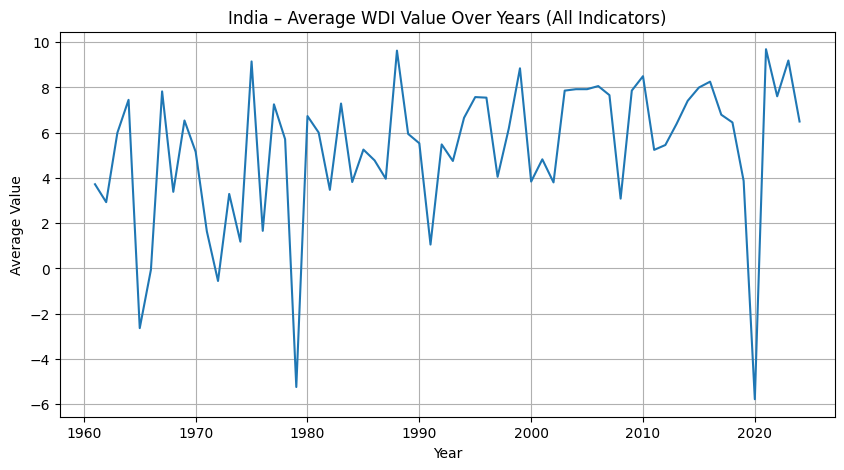

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
india_by_year.plot()
plt.title("India – Average WDI Value Over Years (All Indicators)")
plt.xlabel("Year")
plt.ylabel("Average Value")
plt.grid(True)
plt.show()


**Working without Melt function()**

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/WB_WDI_WIDEF.csv")
df.head()

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MDA,WB_WDI_AG_LND_FRST_ZS,_T,_T,_T,PT_LAR,...,1.175182e+01,1.175487e+01,1.175129e+01,1.175297e+01,1.175276e+01,1.175322e+01,1.175129e+01,1.175487e+01,1.173702e+01,NaN
1,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,PSE,WB_WDI_NY_GDP_FCST_KD,_T,_T,_T,USD_K_2015,...,1.194880e+10,1.304710e+10,1.307280e+10,1.331750e+10,1.349400e+10,1.187960e+10,1.261870e+10,1.279850e+10,1.187650e+10,8.720200e+09
2,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,ECU,WB_WDI_AG_LND_PRCP_MM,_T,_T,_T,MM_Y,...,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,2.274000e+03,NaN,NaN
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SMR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,2.291506e+00,2.344406e+00,2.582655e-01,1.493905e+00,2.065685e+00,-6.647911e+00,1.389779e+01,7.898441e+00,4.019349e-01,NaN
4,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,NZL,WB_WDI_NY_TAX_NIND_KN,_T,_T,_T,XDC_K,...,2.341540e+10,2.453566e+10,2.549904e+10,2.645277e+10,2.701978e+10,2.642800e+10,2.788406e+10,2.952042e+10,2.952592e+10,NaN


In [ ]:
indicator_code = "WB_WDI_NY_GDP_MKTP_KD_ZG"  # replace with your indicator code
one_indicator = df[df["INDICATOR"] == indicator_code]

display(one_indicator.head())

,STRUCTURE,STRUCTURE_ID,ACTION,FREQ,REF_AREA,INDICATOR,SEX,AGE,URBANISATION,UNIT_MEASURE,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
3,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,SMR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,2.291506,2.344406,0.258265,1.493905,2.065685,-6.647911,13.897790,7.898441,0.401935,NaN
37,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,VIR,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,-0.425080,1.600854,-0.735294,1.878307,2.908335,-1.614938,3.667607,-1.311232,NaN,NaN
233,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,THA,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,3.134047,3.435158,4.177681,4.222870,2.114558,-6.050038,1.552166,2.580379,2.017751,2.541821
472,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,MNG,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,2.379836,1.489784,5.636876,7.744881,5.602244,-4.557752,1.636770,5.032710,7.422113,5.122045
849,datastructure,WB.DATA360:DS_DATA360(1.3),I,A,KHM,WB_WDI_NY_GDP_MKTP_KD_ZG,_T,_T,_T,PC_A,...,7.207035,7.905501,8.075039,8.776224,7.936950,-3.555722,3.089843,5.129901,5.007330,5.975109


In [ ]:
year_cols = [c for c in df.columns if c.isdigit()]

In [ ]:
INDIA = one_indicator[one_indicator["REF_AREA"] == "IND"]

In [ ]:
# Average across all rows for India for each year (if multiple breakdown rows exist)
india_by_year = INDIA[year_cols].mean(numeric_only=True)

display(india_by_year.head(10))

,0
1960,NaN
1961,3.722743
1962,2.931128
1963,5.994353
1964,7.452950
1965,-2.635770
1966,-0.055329
1967,7.825963
1968,3.387929
1969,6.539700


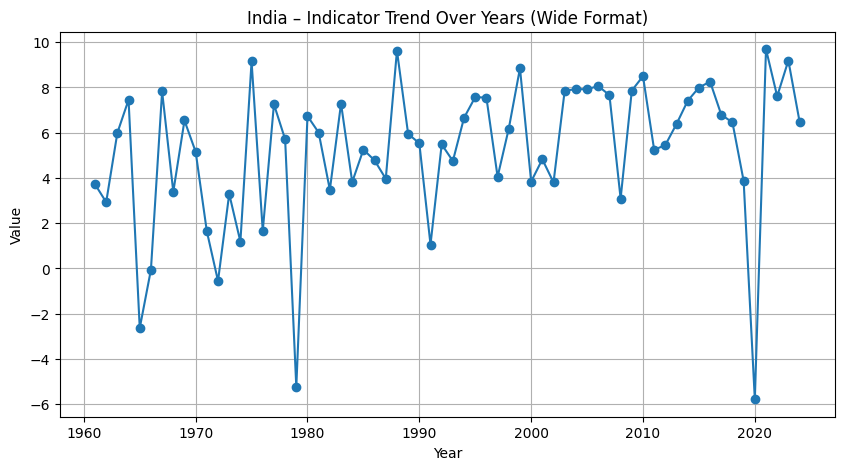

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
india_by_year.astype(float).plot(marker='o')
plt.title("India – Indicator Trend Over Years (Wide Format)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.grid(True)
plt.show()

# Compare Multiple Countries and Basic Operation


1.The dataset was filtered to selected countries using Boolean indexing. Since the WDI file may contain multiple rows per country–indicator, values were aggregated using groupby("REF_AREA") and averaged across duplicate rows. Only year columns were selected to ensure numeric aggregation. This produced a wide-format time series table for comparing India, China, and the United States over time.

2.The WDI dataset has a natural hierarchical structure: each country contains multiple indicators observed over time. This hierarchy was modeled using a Pandas MultiIndex with (REF_AREA, INDICATOR) as the index and years as columns. This structure enables intuitive slicing by country or indicator and supports panel-style time-series analysis without reshaping the dataset.

3.# Slice multiple countries

In [ ]:
countries = ["IND", "CHN", "USA"]

compare = (
    one_indicator[one_indicator["REF_AREA"].isin(countries)]
    .groupby("REF_AREA")[year_cols]
    .mean(numeric_only=True)
)

display(compare.head())

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,,,,,,,,,,,,,,,,,,,,,
CHN,NaN,-27.270000,-5.580000,10.300000,18.18000,16.95000,10.650000,-5.770000,-4.100000,16.9400,...,6.978780,6.775556,6.891266,6.756718,6.068502,2.340188,8.570085,3.134189,5.414843,4.977357
IND,NaN,3.722743,2.931128,5.994353,7.45295,-2.63577,-0.055329,7.825963,3.387929,6.5397,...,7.996254,8.256306,6.795383,6.453851,3.871437,-5.777725,9.689592,7.609365,9.190755,6.494766
USA,NaN,2.300000,6.100000,4.400000,5.80000,6.40000,6.500000,2.500000,4.800000,3.1000,...,2.945550,1.819451,2.457622,2.966505,2.583825,-2.163029,6.055053,2.512375,2.887556,2.793001


In [ ]:
# MultiIndex by (Country, Indicator)
mi_wide = one_indicator.set_index(["REF_AREA", "INDICATOR"])[year_cols]

display(mi_wide.head())


,,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,INDICATOR,,,,,,,,,,,,,,,,,,,,,
SMR,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.291506,2.344406,0.258265,1.493905,2.065685,-6.647911,13.897790,7.898441,0.401935,NaN
VIR,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.425080,1.600854,-0.735294,1.878307,2.908335,-1.614938,3.667607,-1.311232,NaN,NaN
THA,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,5.362146,7.554254,7.999831,6.830996,8.181662,11.122518,8.615982,8.12227,6.55066,...,3.134047,3.435158,4.177681,4.222870,2.114558,-6.050038,1.552166,2.580379,2.017751,2.541821
MNG,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.379836,1.489784,5.636876,7.744881,5.602244,-4.557752,1.636770,5.032710,7.422113,5.122045
KHM,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.207035,7.905501,8.075039,8.776224,7.936950,-3.555722,3.089843,5.129901,5.007330,5.975109


In [ ]:
# All years for India
mi_wide.loc[("IND", indicator_code)]

# Slice multiple countries
mi_wide.loc[["IND", "USA"]]

,,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,INDICATOR,,,,,,,,,,,,,,,,,,,,,
IND,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,3.722743,2.931128,5.994353,7.45295,-2.63577,-0.055329,7.825963,3.387929,6.5397,...,7.996254,8.256306,6.795383,6.453851,3.871437,-5.777725,9.689592,7.609365,9.190755,6.494766
USA,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,2.300000,6.100000,4.400000,5.80000,6.40000,6.500000,2.500000,4.800000,3.1000,...,2.945550,1.819451,2.457622,2.966505,2.583825,-2.163029,6.055053,2.512375,2.887556,2.793001


In [ ]:
#Normalize by country (row-wise operation)
normalized = mi_wide.div(mi_wide.mean(axis=1), axis=0)
display(normalized.head())

,,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,INDICATOR,,,,,,,,,,,,,,,,,,,,,
SMR,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.600187,1.637128,0.180350,1.043213,1.442494,-4.642319,9.704999,5.515580,0.280676,NaN
VIR,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.531451,-2.001450,0.919293,-2.348332,-3.636114,2.019058,-4.585385,1.639353,NaN,NaN
THA,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,0.973433,1.371384,1.452273,1.240085,1.485283,2.01916,1.564128,1.474501,1.189194,...,0.568949,0.623612,0.758408,0.766611,0.383873,-1.098312,0.281777,0.468437,0.366299,0.461437
MNG,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.517191,0.323763,1.225019,1.683135,1.217492,-0.990501,0.355706,1.093720,1.612990,1.113135
KHM,WB_WDI_NY_GDP_MKTP_KD_ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.569864,1.722007,1.758936,1.911671,1.728857,-0.774521,0.673041,1.117415,1.090716,1.301521


In [ ]:
#Year-over-year change
# Ensure year_cols are strings to match DataFrame columns

yoy_change = INDIA[year_cols].pct_change(axis=1) * 100
display(yoy_change.head())

#string_year_cols = [str(y) for y in year_cols]

#yoy_change = INDIA[string_year_cols].pct_change(axis=1) * 100
display(yoy_change.head())

/tmp/ipython-input-444447870.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  yoy_change = INDIA[year_cols].pct_change(axis=1) * 100


,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
68689,NaN,NaN,-21.264291,104.506722,24.332848,-135.36546,-97.90085,-14244.473059,-56.709108,93.029428,...,7.908343,3.252169,-17.694622,-5.025943,-40.01354,-249.239799,-267.706026,-21.468679,20.782154,-29.33371


,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
68689,NaN,NaN,-21.264291,104.506722,24.332848,-135.36546,-97.90085,-14244.473059,-56.709108,93.029428,...,7.908343,3.252169,-17.694622,-5.025943,-40.01354,-249.239799,-267.706026,-21.468679,20.782154,-29.33371


# **RANKING COUNTRIES**


1.   Rank countries by a specific year
2.   Rank Countries for Several Specific Years
3.  Rank Countries by Average Across Multiple Years
4. Produce a Rank Table (Actual Rank Numbers Per Year)
5. Plot: Top 5 Countries Over Time (Wide Format)
6.Plot: Top 5 Countries Over Time (Wide Format)



In [ ]:
#Rank countries by a specific year
rank_2020 = (
    one_indicator.groupby("REF_AREA")["2020"]
    .mean(numeric_only=True)
    .sort_values(ascending=False)
)

display(rank_2020.head(10))


,2020
REF_AREA,
GUY,43.479652
TLS,31.725743
IRL,7.153695
ETH,6.059531
TKM,5.900000
GIN,4.704591
IRN,4.441809
ASM,4.411765
TJK,4.400001


In [ ]:
#rank for multiple years

years = ["2018", "2019", "2020", "2021", "2022"]

rank_multi_years = (
    one_indicator
    .groupby("REF_AREA")[years]
    .mean(numeric_only=True)          # average across breakdown rows
    .sort_values(by="2020", ascending=False)  # sort by one reference year
)

display(rank_multi_years.head(10))


,2018,2019,2020,2021,2022
REF_AREA,,,,,
GUY,4.440913,5.352840,43.479652,20.059998,63.334634
TLS,-0.466502,24.212879,31.725743,5.369802,-20.522479
IRL,7.688659,4.972880,7.153695,16.258188,7.511139
ETH,6.816148,8.364086,6.059531,5.641531,5.321760
TKM,6.200000,6.300000,5.900000,6.200000,6.200000
GIN,6.358492,5.616914,4.704591,5.582333,3.972408
IRN,-3.747960,-2.361435,4.441809,4.130897,4.352811
ASM,2.671119,-0.487805,4.411765,-0.782473,1.735016
TJK,7.599999,7.400000,4.400001,9.400000,8.000000


In [ ]:
#muliplex index benifits
# All indicators for India
mi_wide.loc["IND"]

# GDP for all countries
mi_wide.xs("WB_WDI_NY_GDP_MKTP_KD_ZG", level="INDICATOR")

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,,,,,,,,,,,,,,,,,,,,,
SMR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.291506,2.344406,0.258265,1.493905,2.065685,-6.647911,13.897790,7.898441,0.401935,NaN
VIR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.425080,1.600854,-0.735294,1.878307,2.908335,-1.614938,3.667607,-1.311232,NaN,NaN
THA,NaN,5.362146,7.554254,7.999831,6.830996,8.181662,11.122518,8.615982,8.122270,6.550660,...,3.134047,3.435158,4.177681,4.222870,2.114558,-6.050038,1.552166,2.580379,2.017751,2.541821
MNG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.379836,1.489784,5.636876,7.744881,5.602244,-4.557752,1.636770,5.032710,7.422113,5.122045
KHM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.207035,7.905501,8.075039,8.776224,7.936950,-3.555722,3.089843,5.129901,5.007330,5.975109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GEO,NaN,4.865941,5.113016,4.201879,5.429588,10.558637,7.535663,6.253082,4.455583,4.776504,...,3.351024,3.450215,5.159903,6.062036,5.380719,-6.290472,10.644234,10.958532,7.832201,9.679794
LIC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-2.062947,0.504077,1.884834,2.846890,3.010329,-1.150430,1.279329,3.357591,-0.209388,2.326162
BRN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.392384,-2.477918,1.328727,0.052371,3.868844,1.133573,-1.590763,-1.628332,1.127644,4.052517


In [ ]:
#Option 2: Rank Countries by Average Across Multiple Years (Composite Rank)
years = ["2018", "2019", "2020", "2021", "2022"]

rank_avg_multi_years = (
    one_indicator
    .groupby("REF_AREA")[years]
    .mean(numeric_only=True)
    .assign(avg_5yr=lambda x: x.mean(axis=1))  # row-wise mean across selected years
    .sort_values(by="avg_5yr", ascending=False)
)

display(rank_avg_multi_years.head(10))


#🧠 Explanation

#.assign(avg_5yr=...) → creates a new column

#x.mean(axis=1) → mean across years for each country

#You now rank by 5-year average, which is great for reports


,2018,2019,2020,2021,2022,avg_5yr
REF_AREA,,,,,,
GUY,4.440913,5.352840,43.479652,20.059998,63.334634,27.333607
IRL,7.688659,4.972880,7.153695,16.258188,7.511139,8.716912
TLS,-0.466502,24.212879,31.725743,5.369802,-20.522479,8.063889
TJK,7.599999,7.400000,4.400001,9.400000,8.000000,7.360000
MDV,8.568956,6.923060,-32.908829,37.507870,13.826090,6.783429
RWA,8.516467,9.447385,-3.373687,10.858432,8.161207,6.721961
MCO,5.697901,7.120890,-13.239105,22.232216,11.266296,6.615639
BGD,7.319413,7.881915,3.448018,6.938679,7.099829,6.537571
ETH,6.816148,8.364086,6.059531,5.641531,5.321760,6.440611


In [ ]:
#Option 3: Produce a Rank Table (Actual Rank Numbers Per Year)

years = ["2018", "2019", "2020", "2021", "2022"]

country_year_values = (
    one_indicator
    .groupby("REF_AREA")[years]
    .mean(numeric_only=True)
)

ranks_per_year = country_year_values.rank(ascending=False, method="dense")

display(ranks_per_year.head(10))


,2018,2019,2020,2021,2022
REF_AREA,,,,,
ABW,123.0,197.0,249.0,11.0,19.0
AFE,154.0,162.0,101.0,151.0,155.0
AFG,216.0,94.0,88.0,256.0,251.0
AFW,135.0,105.0,128.0,202.0,113.0
AGO,238.0,228.0,136.0,209.0,124.0
ALB,108.0,160.0,116.0,41.0,99.0
AND,198.0,164.0,226.0,49.0,22.0
ARB,155.0,178.0,160.0,157.0,50.0
ARE,202.0,195.0,204.0,154.0,42.0


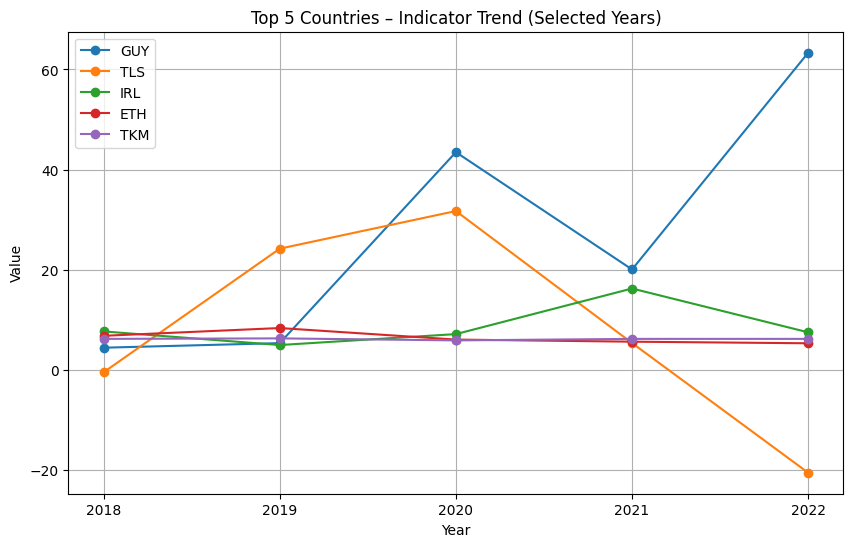

In [ ]:
#Optional Plot: Top 5 Countries Over Time (Wide Format)
top5 = rank_multi_years.head(5)

plt.figure(figsize=(10,6))
for country in top5.index:
    plt.plot(years, top5.loc[country, years], marker='o', label=country)

plt.title("Top 5 Countries – Indicator Trend (Selected Years)")
plt.xlabel("Year")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.show()


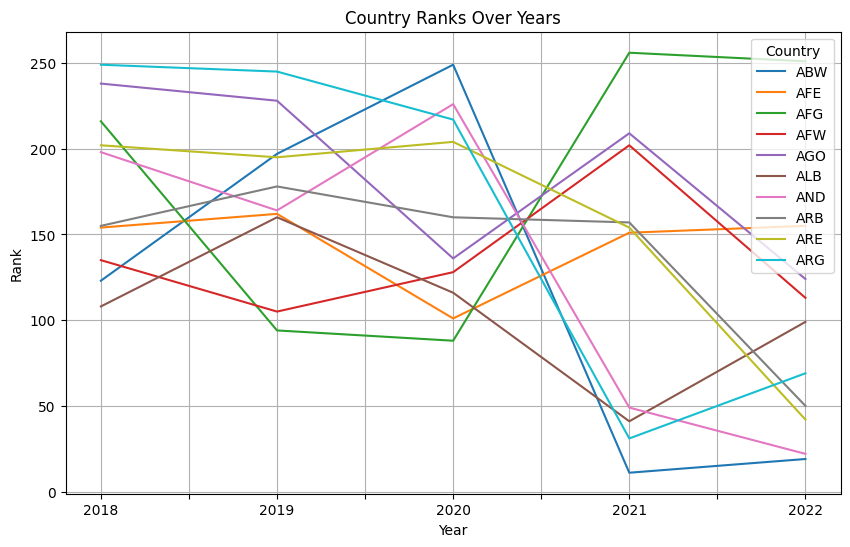

In [ ]:
ranks_per_year.head(10).T.plot(figsize=(10,6))
plt.title("Country Ranks Over Years")
plt.xlabel("Year")
plt.ylabel("Rank")
plt.legend(title="Country")
plt.grid(True)
plt.show()

**Analysis  of World Bank WDI Data for India, China, and the USA**


# Analysis of World Bank WDI Data for India, China, and the USA

1.   Define target countries and indicators
2.  Compute average GDP growth over time for each country
3. Mean life expectancy per country (across all years
4. Percent change: Year-over-year growth in total population for India
5. Ranking: rank countries by CO2 emissions per capita in 2020


In [ ]:
print(f"Dataset shape: {df.shape}")
print("Sample columns:", df.columns[:6].tolist())

Dataset shape: (294796, 106)
Sample columns: ['STRUCTURE', 'STRUCTURE_ID', 'ACTION', 'FREQ', 'REF_AREA', 'INDICATOR']


In [ ]:
year_pattern = r'^\d{4}$'
year_cols = df.filter(regex=year_pattern, axis=1).columns.tolist()
print("Year columns detected:", year_cols[:5], "...", year_cols[-2:])

Year columns detected: ['1960', '1961', '1962', '1963', '1964'] ... ['2023', '2024']


In [ ]:
df.rename(columns=lambda x: int(x) if x.isdigit() else x, inplace=True)
year_cols = [int(col) for col in year_cols]
year_cols = sorted([col for col in df.columns if isinstance(col, int)])
print("Year columns as ints:", year_cols[:5], "...", year_cols[-2:])

Year columns as ints: [1960, 1961, 1962, 1963, 1964] ... [2023, 2024]


In [ ]:
# Define target countries and indicators
countries = ["IND", "CHN", "USA"]
indicators = [
    "GDP growth (annual %)",
    "Population, total",
    "Life expectancy at birth, total (years)",
    "Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)"
]

# Filter the DataFrame for these countries and indicators
df_sub = df[
    (df["REF_AREA"].isin(countries)) &
    (df["INDICATOR_LABEL"].isin(indicators))
].copy()
print(f"Filtered rows: {df_sub.shape[0]}")
print(df_sub[["REF_AREA","INDICATOR_LABEL"]].drop_duplicates())

Filtered rows: 12
       REF_AREA                                    INDICATOR_LABEL
22233       CHN  Carbon dioxide (CO2) emissions excluding LULUC...
27406       CHN                              GDP growth (annual %)
65516       USA                                  Population, total
68689       IND                              GDP growth (annual %)
82516       USA  Carbon dioxide (CO2) emissions excluding LULUC...
83239       CHN                                  Population, total
86460       CHN            Life expectancy at birth, total (years)
148023      IND            Life expectancy at birth, total (years)
171675      IND  Carbon dioxide (CO2) emissions excluding LULUC...
188522      USA            Life expectancy at birth, total (years)
238649      USA                              GDP growth (annual %)
291288      IND                                  Population, total


In [ ]:
# Pivot to wide layout with MultiIndex for demonstration (not using melt)
# Reset the index to ensure 'REF_AREA' and 'INDICATOR_LABEL' are available as columns
df_sub = df_sub.reset_index(inplace=False)
df_sub = df_sub.set_index(["REF_AREA", "INDICATOR_LABEL"])[year_cols]  # keep only year columns
print(df_sub.head(3))

                                                                    1960  \
REF_AREA INDICATOR_LABEL                                                   
CHN      Carbon dioxide (CO2) emissions excluding LULUCF...          NaN   
         GDP growth (annual %)                                       NaN   
USA      Population, total                                   180671000.0   

                                                                     1961  \
REF_AREA INDICATOR_LABEL                                                    
CHN      Carbon dioxide (CO2) emissions excluding LULUCF...           NaN   
         GDP growth (annual %)                              -2.727000e+01   
USA      Population, total                                   1.836910e+08   

                                                                     1962  \
REF_AREA INDICATOR_LABEL                                                    
CHN      Carbon dioxide (CO2) emissions excluding LULUCF...           NaN   
  

In [ ]:
# Ranking: rank countries by CO2 emissions per capita in 2020
co2 = df_sub.xs("Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)", level="INDICATOR_LABEL")
rank2020 = co2[2020].rank(ascending=False)
print(rank2020)

REF_AREA
CHN    2.0
USA    1.0
IND    3.0
Name: 2020, dtype: float64


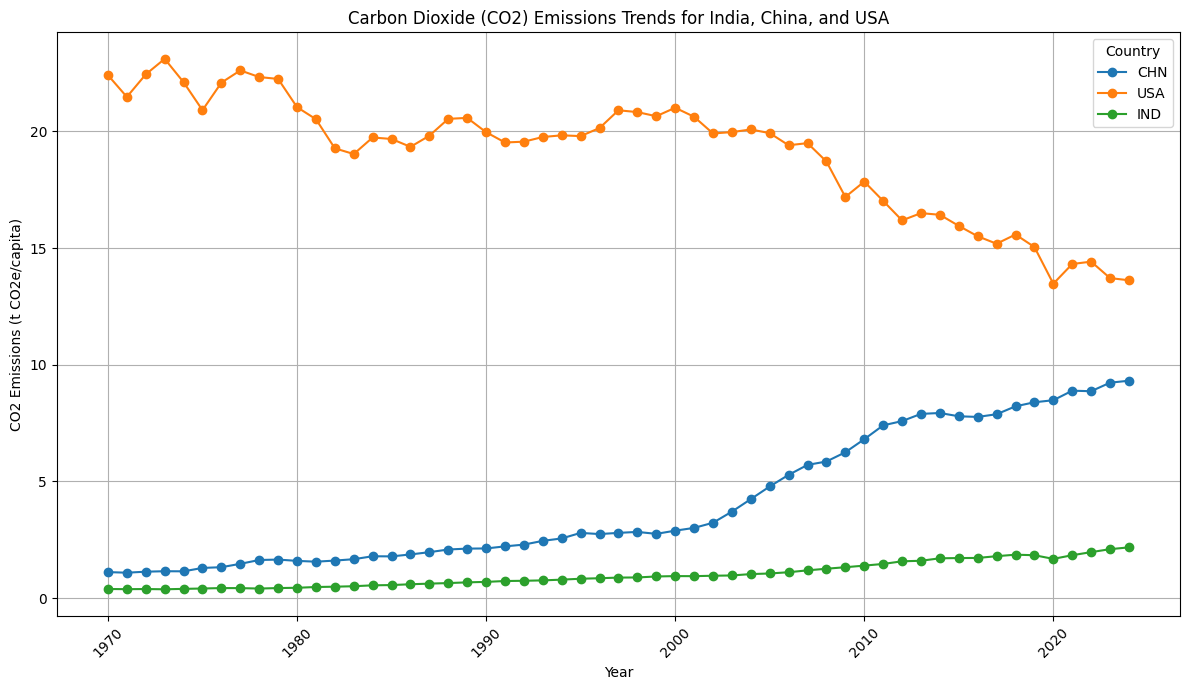

In [ ]:
import matplotlib.pyplot as plt

# 'co2' DataFrame already contains CO2 emissions data for IND, CHN, USA
# from a previous step: co2 = df_sub.xs("Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)", level="INDICATOR_LABEL")

plt.figure(figsize=(12, 7))
co2.T.plot(ax=plt.gca(), marker='o', linestyle='-')
plt.title('Carbon Dioxide (CO2) Emissions Trends for India, China, and USA')
plt.xlabel('Year')
plt.ylabel('CO2 Emissions (t CO2e/capita)')
plt.grid(True)
plt.legend(title='Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Example: Compute average GDP growth over time for each country
gdp = df_sub.xs("GDP growth (annual %)", level="INDICATOR_LABEL") # select GDP
gdp_mean_by_country = gdp.mean(axis=1).sort_values(ascending=False)
print("Average GDP growth (%):")
print(gdp_mean_by_country)

Average GDP growth (%):
REF_AREA
CHN    7.920939
IND    5.241188
USA    3.015674
dtype: float64


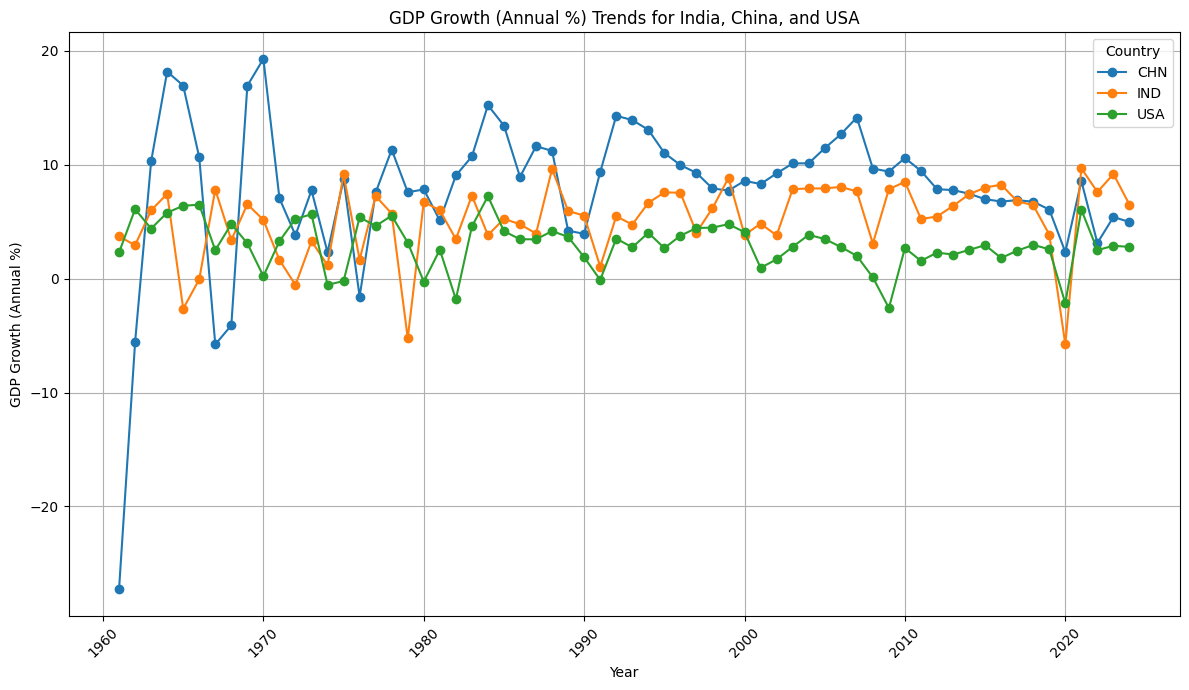

In [ ]:
import matplotlib.pyplot as plt

# 'gdp' DataFrame already contains GDP growth data for IND, CHN, USA
# from a previous step: gdp = df_sub.xs("GDP growth (annual %)", level="INDICATOR_LABEL")

plt.figure(figsize=(12, 7))
gdp.T.plot(ax=plt.gca(), marker='o', linestyle='-')
plt.title('GDP Growth (Annual %) Trends for India, China, and USA')
plt.xlabel('Year')
plt.ylabel('GDP Growth (Annual %)')
plt.grid(True)
plt.legend(title='Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# GroupBy example: Mean life expectancy per country (across all years)
life = df_sub.xs("Life expectancy at birth, total (years)", level="INDICATOR_LABEL")
life_mean = life.mean(axis=1).sort_values()
print("\nMean Life Expectancy (years):")
print(life_mean)


Mean Life Expectancy (years):
REF_AREA
IND    58.652172
CHN    66.990781
USA    74.961280
dtype: float64


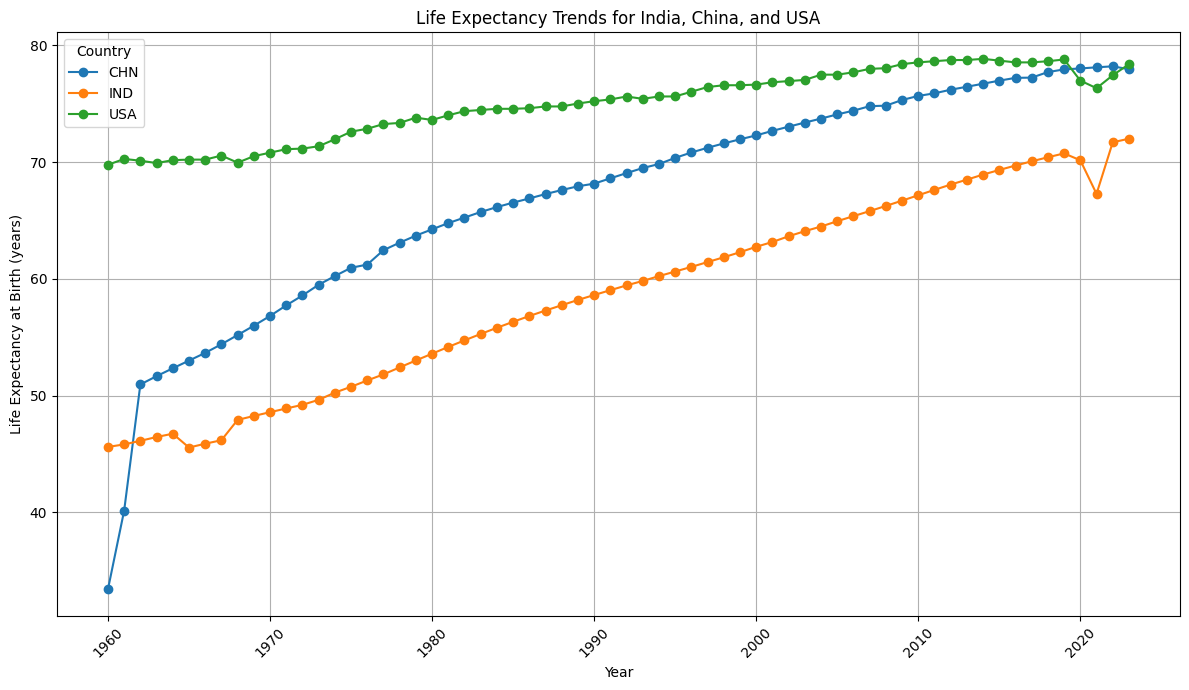

In [ ]:
import matplotlib.pyplot as plt

# 'life' DataFrame already contains life expectancy data for IND, CHN, USA
# from a previous step: life = df_sub.xs("Life expectancy at birth, total (years)", level="INDICATOR_LABEL")

plt.figure(figsize=(12, 7))
life.T.plot(ax=plt.gca(), marker='o', linestyle='-')
plt.title('Life Expectancy Trends for India, China, and USA')
plt.xlabel('Year')
plt.ylabel('Life Expectancy at Birth (years)')
plt.grid(True)
plt.legend(title='Country')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Percent change: Year-over-year growth in total population for India
pop = df_sub.xs("Population, total", level="INDICATOR_LABEL")
pop_india = pop.loc["IND"].T # transpose: index=year, values=population
pop_india_pct = pop_india.pct_change() * 100
print("\nPopulation % change (India) in 5-year steps:")
print(pop_india_pct.dropna().iloc[::5]) # show every 5th year for brevity


Population % change (India) in 5-year steps:
1961    2.425373
1966    2.162667
1971    2.240872
1976    2.380520
1981    2.377556
1986    2.335111
1991    2.191444
1996    2.017848
2001    1.888214
2006    1.576422
2011    1.426912
2016    1.198758
2021    0.826041
Name: IND, dtype: float64


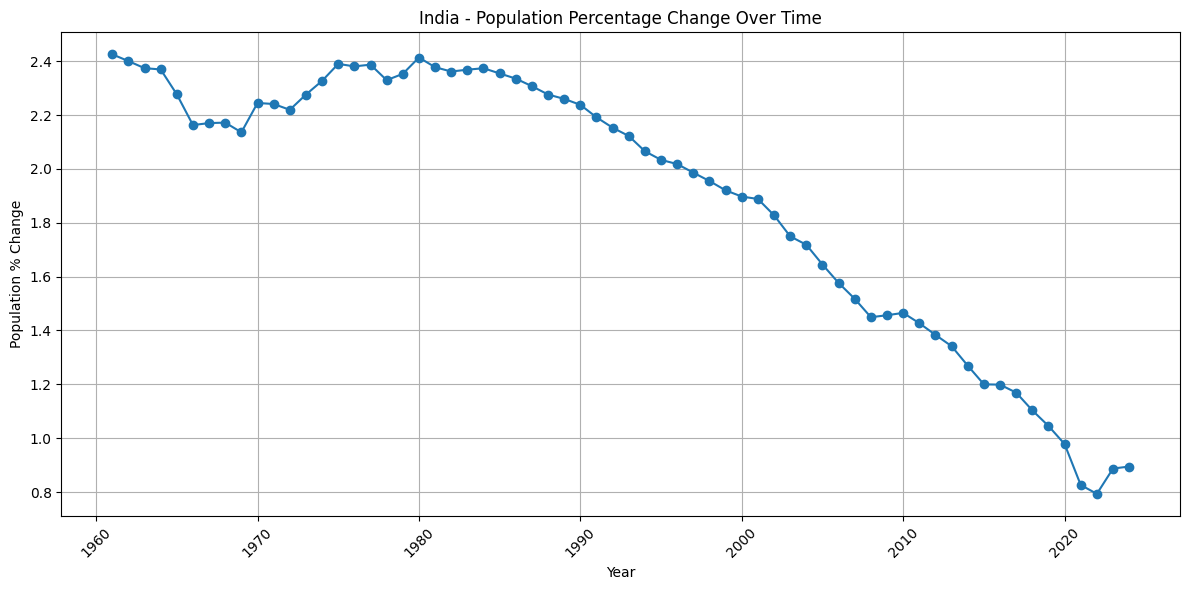

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
pop_india_pct.plot(marker='o', linestyle='-')
plt.title('India - Population Percentage Change Over Time')
plt.xlabel('Year')
plt.ylabel('Population % Change')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# We already set a MultiIndex above: ensure it is sorted for clarity
df_multi = df_sub.sort_index()
print(df_multi.head())

                                                                     1960  \
REF_AREA INDICATOR_LABEL                                                    
CHN      Carbon dioxide (CO2) emissions excluding LULUCF...           NaN   
         GDP growth (annual %)                                        NaN   
         Life expectancy at birth, total (years)             3.341900e+01   
         Population, total                                   6.670700e+08   
IND      Carbon dioxide (CO2) emissions excluding LULUCF...           NaN   

                                                                     1961  \
REF_AREA INDICATOR_LABEL                                                    
CHN      Carbon dioxide (CO2) emissions excluding LULUCF...           NaN   
         GDP growth (annual %)                              -2.727000e+01   
         Life expectancy at birth, total (years)             4.015800e+01   
         Population, total                                   6.603300e+08  

In [ ]:
df_sub.xs("Population, total", level="INDICATOR_LABEL")

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,,,,,,,,,,,,,,,,,,,,,
USA,180671000.0,183691000.0,186538000.0,189242000.0,191889000.0,194303000.0,196560000.0,198712000.0,200706000.0,202677000.0,...,3.218151e+08,3.243533e+08,3.266086e+08,3.285296e+08,3.302262e+08,3.315777e+08,3.320998e+08,3.340173e+08,3.368062e+08,3.401110e+08
CHN,667070000.0,660330000.0,665770000.0,682335000.0,698355000.0,715185000.0,735400000.0,754550000.0,774510000.0,796025000.0,...,1.379860e+09,1.387790e+09,1.396215e+09,1.402760e+09,1.407745e+09,1.411100e+09,1.412360e+09,1.412175e+09,1.410710e+09,1.408975e+09
IND,435990338.0,446564729.0,457283090.0,468138575.0,479229598.0,490140146.0,500740247.0,511606372.0,522716889.0,533880544.0,...,1.328024e+09,1.343944e+09,1.359657e+09,1.374659e+09,1.389030e+09,1.402618e+09,1.414204e+09,1.425423e+09,1.438070e+09,1.450936e+09


In [ ]:
df_sub.sort_values(by=2022, ascending=False).head()

,,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
REF_AREA,INDICATOR_LABEL,,,,,,,,,,,,,,,,,,,,,
IND,"Population, total",4.359903e+08,4.465647e+08,4.572831e+08,4.681386e+08,4.792296e+08,4.901401e+08,5.007402e+08,5.116064e+08,5.227169e+08,5.338805e+08,...,1.328024e+09,1.343944e+09,1.359657e+09,1.374659e+09,1.389030e+09,1.402618e+09,1.414204e+09,1.425423e+09,1.438070e+09,1.450936e+09
CHN,"Population, total",6.670700e+08,6.603300e+08,6.657700e+08,6.823350e+08,6.983550e+08,7.151850e+08,7.354000e+08,7.545500e+08,7.745100e+08,7.960250e+08,...,1.379860e+09,1.387790e+09,1.396215e+09,1.402760e+09,1.407745e+09,1.411100e+09,1.412360e+09,1.412175e+09,1.410710e+09,1.408975e+09
USA,"Population, total",1.806710e+08,1.836910e+08,1.865380e+08,1.892420e+08,1.918890e+08,1.943030e+08,1.965600e+08,1.987120e+08,2.007060e+08,2.026770e+08,...,3.218151e+08,3.243533e+08,3.266086e+08,3.285296e+08,3.302262e+08,3.315777e+08,3.320998e+08,3.340173e+08,3.368062e+08,3.401110e+08
CHN,"Life expectancy at birth, total (years)",3.341900e+01,4.015800e+01,5.095900e+01,5.167000e+01,5.234300e+01,5.300100e+01,5.366200e+01,5.440100e+01,5.519100e+01,5.598800e+01,...,7.697500e+01,7.721400e+01,7.723500e+01,7.770900e+01,7.794000e+01,7.801900e+01,7.811700e+01,7.820200e+01,7.795300e+01,NaN
USA,"Life expectancy at birth, total (years)",6.977073e+01,7.027073e+01,7.011951e+01,6.991707e+01,7.016585e+01,7.021463e+01,7.021220e+01,7.056098e+01,6.995122e+01,7.050732e+01,...,7.869024e+01,7.853902e+01,7.853902e+01,7.863902e+01,7.878780e+01,7.698049e+01,7.632927e+01,7.743415e+01,7.838537e+01,NaN


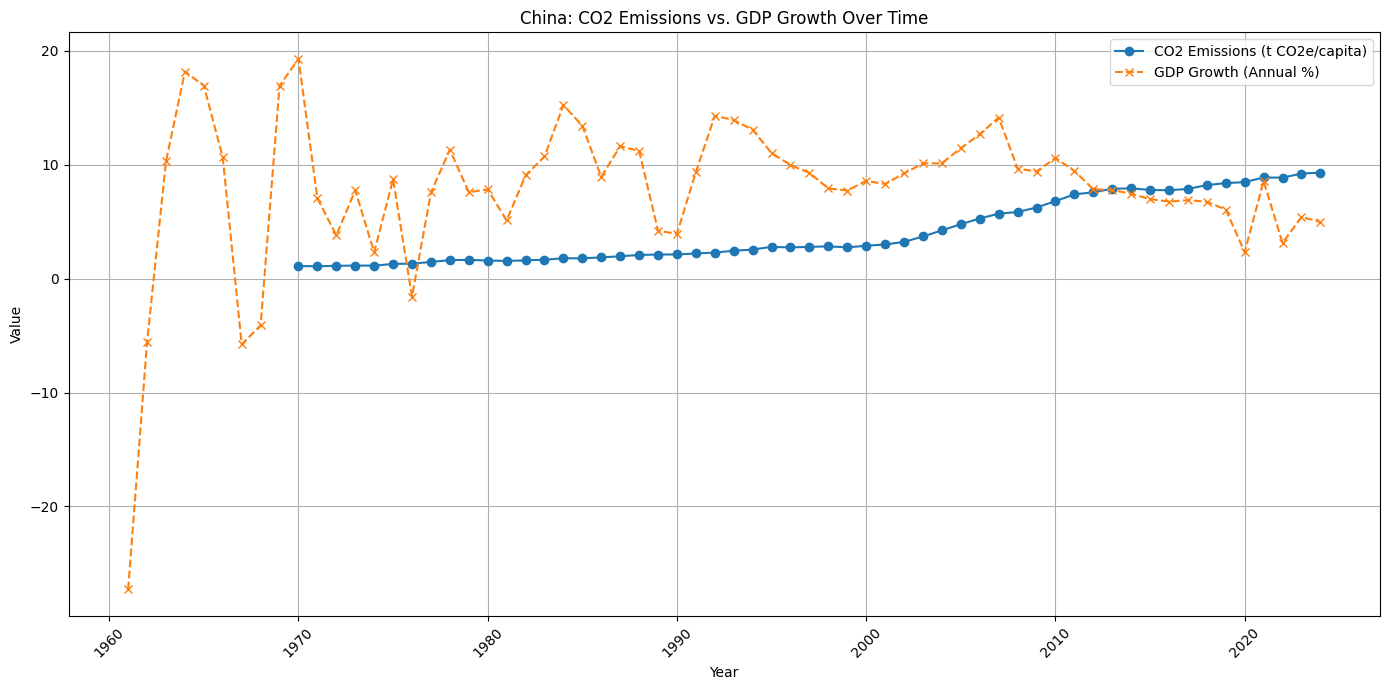

In [ ]:
import matplotlib.pyplot as plt

# Extract China's CO2 emissions data
china_co2 = df_sub.xs("Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)", level="INDICATOR_LABEL").loc["CHN"]

# Extract China's GDP growth data
china_gdp = df_sub.xs("GDP growth (annual %)", level="INDICATOR_LABEL").loc["CHN"]

plt.figure(figsize=(14, 7))

# Plot CO2 Emissions
plt.plot(china_co2.index, china_co2.values, label='CO2 Emissions (t CO2e/capita)', marker='o', linestyle='-')

# Plot GDP Growth
plt.plot(china_gdp.index, china_gdp.values, label='GDP Growth (Annual %)', marker='x', linestyle='--')

plt.title('China: CO2 Emissions vs. GDP Growth Over Time')
plt.xlabel('Year')
plt.ylabel('Value')
plt.grid(True)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df_sub.loc['CHN']

,1960,1961,1962,1963,1964,1965,1966,1967,1968,1969,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
INDICATOR_LABEL,,,,,,,,,,,,,,,,,,,,,
Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.790570e+00,7.763225e+00,7.878027e+00,8.217736e+00,8.391476e+00,8.478583e+00,8.887157e+00,8.864825e+00,9.230276e+00,9.315089e+00
GDP growth (annual %),NaN,-2.727000e+01,-5.580000e+00,1.030000e+01,1.818000e+01,1.695000e+01,1.065000e+01,-5.770000e+00,-4.100000e+00,1.694000e+01,...,6.978780e+00,6.775556e+00,6.891266e+00,6.756718e+00,6.068502e+00,2.340188e+00,8.570085e+00,3.134189e+00,5.414843e+00,4.977357e+00
"Population, total",6.670700e+08,6.603300e+08,6.657700e+08,6.823350e+08,6.983550e+08,7.151850e+08,7.354000e+08,7.545500e+08,7.745100e+08,7.960250e+08,...,1.379860e+09,1.387790e+09,1.396215e+09,1.402760e+09,1.407745e+09,1.411100e+09,1.412360e+09,1.412175e+09,1.410710e+09,1.408975e+09
"Life expectancy at birth, total (years)",3.341900e+01,4.015800e+01,5.095900e+01,5.167000e+01,5.234300e+01,5.300100e+01,5.366200e+01,5.440100e+01,5.519100e+01,5.598800e+01,...,7.697500e+01,7.721400e+01,7.723500e+01,7.770900e+01,7.794000e+01,7.801900e+01,7.811700e+01,7.820200e+01,7.795300e+01,NaN


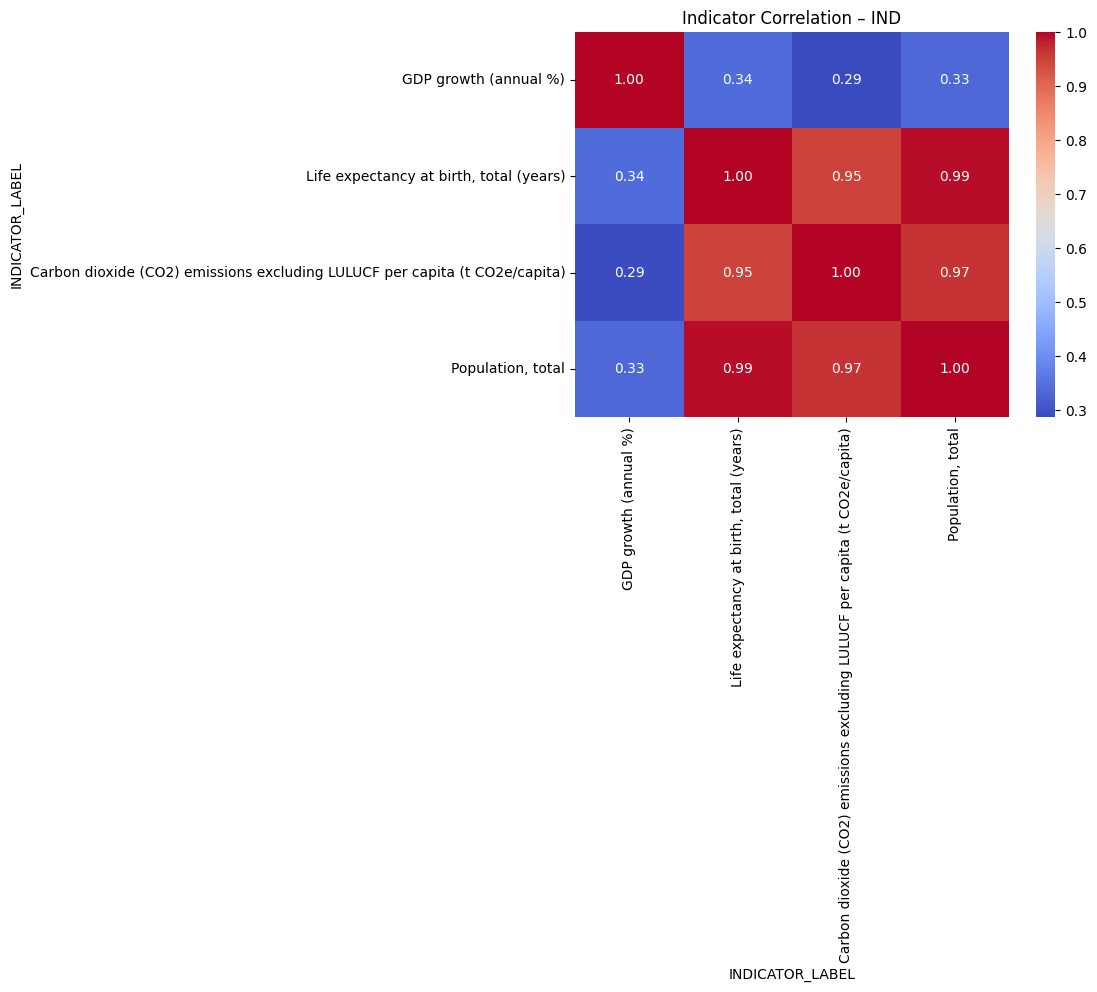

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_correlation(country_code):
    # Filter df_sub where 'REF_AREA' column matches country_code
    country_data = df_sub[df_sub['REF_AREA'] == country_code]

    # Then set 'INDICATOR_LABEL' as index and select year columns to prepare for transpose and corr
    # The year_cols are currently integers from the initial setup of df_sub, ensure they are correctly used
    year_cols_int = [col for col in country_data.columns if isinstance(col, int)]
    country_df = country_data.set_index('INDICATOR_LABEL')[year_cols_int]

    corr = country_df.T.corr()              # rows = years → correlation across indicators

    plt.figure(figsize=(7,5))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title(f"Indicator Correlation – {country_code}")
    plt.show()

plot_correlation("IND")


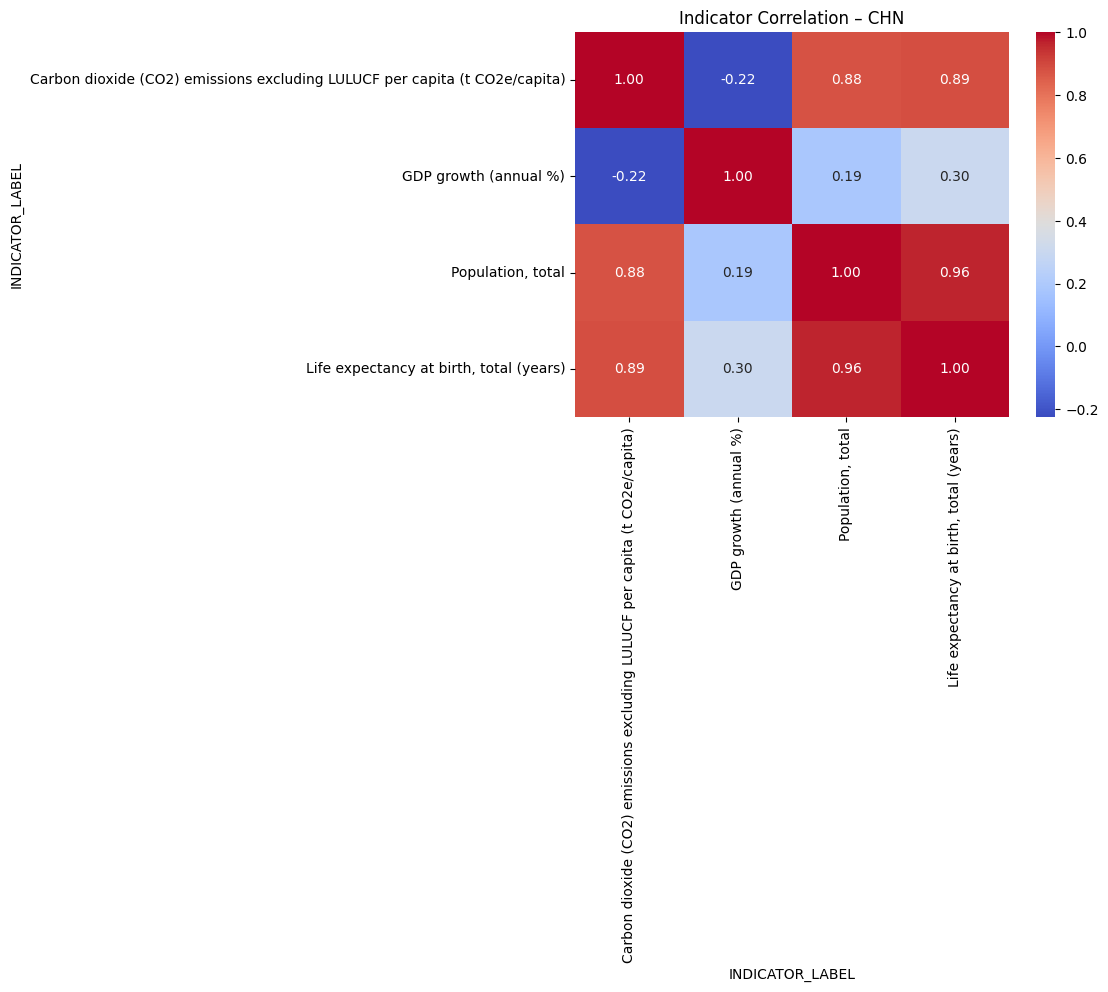

In [ ]:
plot_correlation("CHN")


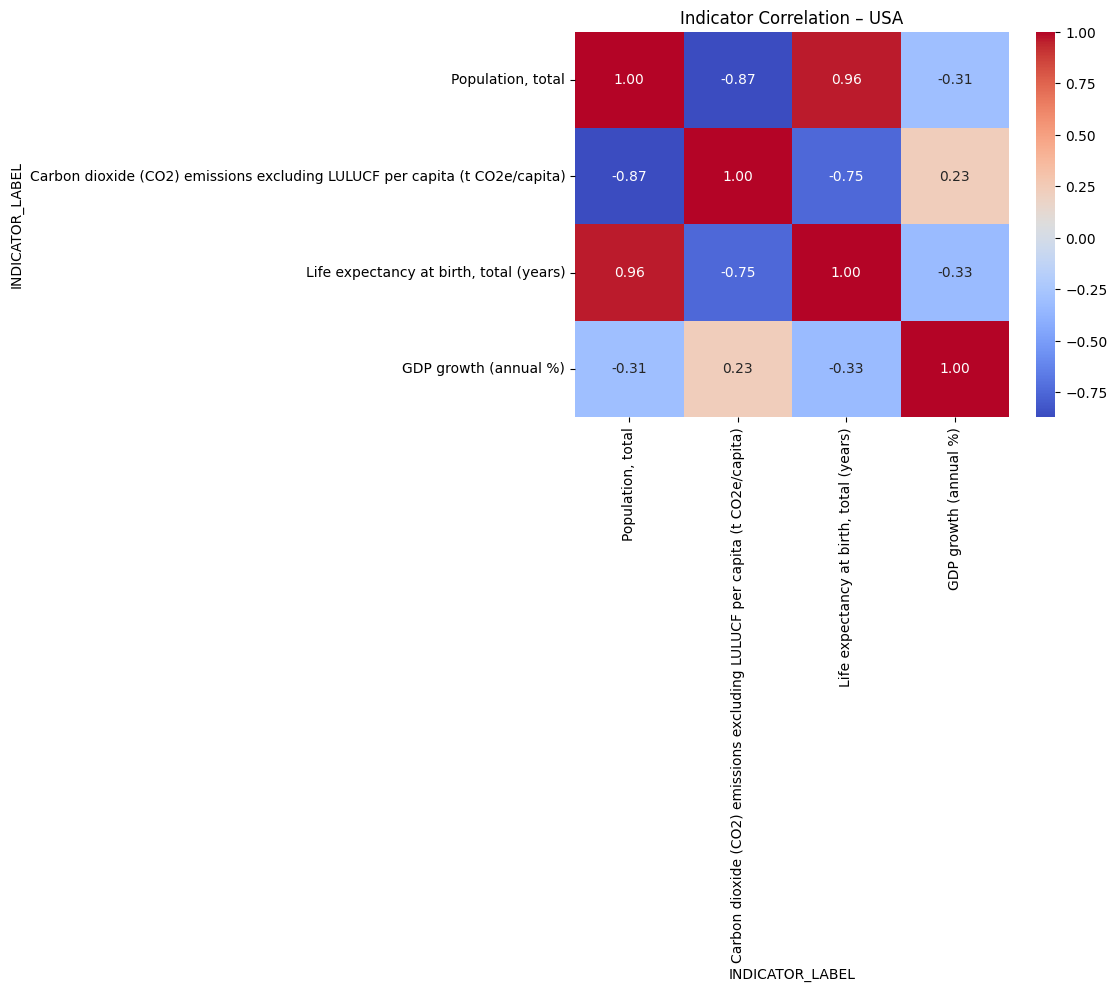

In [ ]:
plot_correlation("USA")

In [ ]:
# Combine multiple indicators into one wide table per country
df_wide = df_multi.unstack(level="INDICATOR_LABEL")
df_wide.columns = df_wide.columns.swaplevel(0,1)  # make (Indicator, Year) to (Year, Indicator)
df_wide = df_wide.sort_index(axis=1, level=0)
print(df_wide.head())

INDICATOR_LABEL Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)  \
                                                                                      1960   
REF_AREA                                                                                     
CHN                                                            NaN                           
IND                                                            NaN                           
USA                                                            NaN                           

INDICATOR_LABEL                                               ...  \
                1961 1962 1963 1964 1965 1966 1967 1968 1969  ...   
REF_AREA                                                      ...   
CHN              NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
IND              NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
USA              NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   

INDICATOR_LABEL Popu

In [ ]:
df_wide

INDICATOR_LABEL Carbon dioxide (CO2) emissions excluding LULUCF per capita (t CO2e/capita)  \
                                                                                      1960   
REF_AREA                                                                                     
CHN                                                            NaN                           
IND                                                            NaN                           
USA                                                            NaN                           

INDICATOR_LABEL                                               ...  \
                1961 1962 1963 1964 1965 1966 1967 1968 1969  ...   
REF_AREA                                                      ...   
CHN              NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
IND              NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   
USA              NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...   

INDICATOR_LABEL Population, total                                            \
                             2015          2016          2017          2018   
REF_AREA                                                                      
CHN                  1.379860e+09  1.387790e+09  1.396215e+09  1.402760e+09   
IND                  1.328024e+09  1.343944e+09  1.359657e+09  1.374659e+09   
USA                  3.218151e+08  3.243533e+08  3.266086e+08  3.285296e+08   

INDICATOR_LABEL                                                          \
                         2019          2020          2021          2022   
REF_AREA                                                                  
CHN              1.407745e+09  1.411100e+09  1.412360e+09  1.412175e+09   
IND              1.389030e+09  1.402618e+09  1.414204e+09  1.425423e+09   
USA              3.302262e+08  3.315777e+08  3.320998e+08  3.340173e+08   

INDICATOR_LABEL                              
                         2023          2024  
REF_AREA                                     
CHN              1.410710e+09  1.408975e+09  
IND              1.438070e+09  1.450936e+09  
USA              3.368062e+08  3.401110e+08  

[3 rows x 260 columns]